In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [178]:
df = pd.read_csv("/content/customer_churn (1).csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,$29.85,$29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed Check,$56.95,$1889.5,NO
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,$53.85,$108.15,YES
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,bank transfer (automatic),$42.3,$1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,ELECTRONIC CHECK,$70.7,$nan,yes


In [179]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12055 entries, 0 to 12054
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            12055 non-null  object 
 1   SeniorCitizen     12055 non-null  int64  
 2   Partner           12055 non-null  object 
 3   Dependents        12055 non-null  object 
 4   tenure            11451 non-null  float64
 5   PhoneService      12055 non-null  object 
 6   MultipleLines     12055 non-null  object 
 7   InternetService   12055 non-null  object 
 8   OnlineSecurity    12055 non-null  object 
 9   OnlineBackup      12055 non-null  object 
 10  DeviceProtection  12055 non-null  object 
 11  TechSupport       12055 non-null  object 
 12  StreamingTV       12055 non-null  object 
 13  StreamingMovies   12055 non-null  object 
 14  Contract          12055 non-null  object 
 15  PaperlessBilling  12055 non-null  object 
 16  PaymentMethod     12055 non-null  object

,SeniorCitizen,tenure
count,12055.000000,11451.000000
mean,0.117959,31.237796
std,0.322573,25.027111
min,0.000000,-3.000000
25%,0.000000,6.000000
50%,0.000000,28.000000
75%,0.000000,54.000000
max,1.000000,74.000000


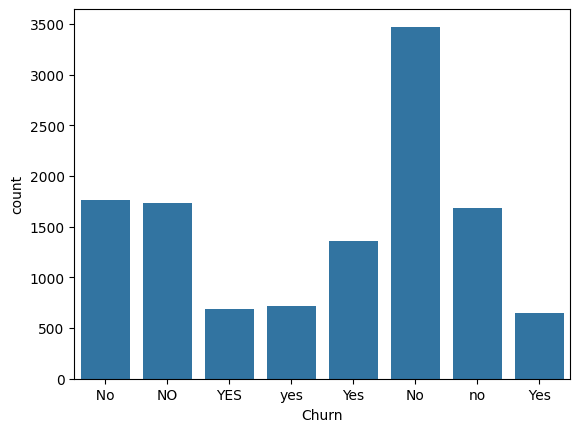

In [180]:
sns.countplot(x='Churn', data=df)
plt.show()

In [181]:
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [182]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [183]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

# 1. IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings("ignore")

# 2. LOAD DATA

In [ ]:
df = pd.read_csv("/content/customer_churn (1).csv")

print("Dataset Shape:", df.shape)
df.head()

# 3. DATA CLEANING
# Remove extra spaces from column names

In [ ]:
df.columns = df.columns.str.strip()

# Clean all string columns (remove spaces & lowercase)

In [ ]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Standardize target column

In [ ]:
df["Churn"] = df["Churn"].replace({
    "yes": 1,
    "no": 0
})

# Remove currency symbols

In [ ]:
df["MonthlyCharges"] = df["MonthlyCharges"].str.replace(r'[$£]', '', regex=True)
df["TotalCharges"] = df["TotalCharges"].str.replace(r'[$£]', '', regex=True)

# Convert to numeric

In [ ]:
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors='coerce')
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df["tenure"] = pd.to_numeric(df["tenure"], errors='coerce')

# Handle missing values

In [ ]:
df = df.dropna()

print("Cleaned shape:", df.shape)

# 4. EXPLORATORY DATA ANALYSIS (EDA)

# Set plot size

In [ ]:
plt.figure(figsize=(6,4))

# Churn distribution

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

# Tenure Distribution

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['tenure'], bins=30)
plt.title("Tenure Distribution")
plt.show()

# Monthly Charges

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['MonthlyCharges'], bins=30)
plt.title("Monthly Charges Distribution")
plt.show()

# Contract vs Churn

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=45)
plt.show()

# Payment Method vs Churn

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=45)
plt.show()

# Internet Service vs Churn

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Internet Service vs Churn")
plt.show()

# Correlation Heatmap (Multivariate)

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 5. ENCODING CATEGORICAL VARIABLES

In [ ]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# 6. TRAIN-TEST SPLIT

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# 7. FEATURE SCALING

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 8. MODEL BUILDING - LOGISTIC REGRESSION

In [ ]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

# 9. MODEL EVALUATION

In [ ]:
y_pred = model.predict(X_test_scaled)

# Accuracy

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report

In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
results = []

In [ ]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([model_name, acc, prec, rec, f1])

In [ ]:
print(f"\n{model_name} Results:")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
evaluate_model("Decision Tree", dt, X_train_scaled, X_test_scaled, y_train, y_test)

In [ ]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)
evaluate_model("Bagging", bag, X_train_scaled, X_test_scaled, y_train, y_test)

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_model("Random Forest", rf, X_train_scaled, X_test_scaled, y_train, y_test)

In [ ]:
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
evaluate_model("AdaBoost", ada, X_train_scaled, X_test_scaled, y_train, y_test)

In [ ]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
evaluate_model("Gradient Boosting", gb, X_train_scaled, X_test_scaled, y_train, y_test)

In [ ]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
evaluate_model("XGBoost", xgb, X_train_scaled, X_test_scaled, y_train, y_test)

In [ ]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
results_df

In [ ]:
results_df.set_index("Model")[["Accuracy", "Recall", "F1 Score"]].plot(
    kind='bar', figsize=(10,6)
)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=3,
    scoring='recall',
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

print("Best Parameters (RF):", rf_grid.best_params_)

rf_best = rf_grid.best_estimator_

In [ ]:
evaluate_model("Tuned Random Forest", rf_best, X_train_scaled, X_test_scaled, y_train, y_test)

In [ ]:
gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_params,
    cv=3,
    scoring='recall',
    n_jobs=-1
)

gb_grid.fit(X_train_scaled, y_train)

print("Best Parameters (GB):", gb_grid.best_params_)

gb_best = gb_grid.best_estimator_

In [ ]:
evaluate_model("Tuned Gradient Boosting", gb_best, X_train_scaled, X_test_scaled, y_train, y_test)

In [ ]:
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1]
}

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_params,
    cv=3,
    scoring='recall',
    n_jobs=-1
)

xgb_grid.fit(X_train_scaled, y_train)

print("Best Parameters (XGB):", xgb_grid.best_params_)

xgb_best = xgb_grid.best_estimator_

In [ ]:
evaluate_model("Tuned XGBoost", xgb_best, X_train_scaled, X_test_scaled, y_train, y_test)

In [ ]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
results_df

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities

In [ ]:
y_prob_xgb = xgb_best.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

# Compute AUC

In [ ]:
auc_score = roc_auc_score(y_test, y_prob_xgb)

# Plot ROC curve

In [ ]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc_score:.2f})")
plt.plot([0,1], [0,1], 'k--')  # diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

# Get probabilities

In [ ]:
y_prob_lr = model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf_best.predict_proba(X_test_scaled)[:, 1]
y_prob_gb = gb_best.predict_proba(X_test_scaled)[:, 1]
y_prob_xgb = xgb_best.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curves

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# AUC scores

In [ ]:
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_gb = roc_auc_score(y_test, y_prob_gb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Plot all

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predictions
y_pred_xgb = xgb_best.predict(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - XGBoost")

plt.show()

In [ ]:
models = {
    "Logistic Regression": model,
    "Random Forest": rf_best,
    "Gradient Boosting": gb_best,
    "XGBoost": xgb_best
}

for name, mdl in models.items():
    y_pred = mdl.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Feature importance from Random Forest

In [ ]:
import pandas as pd

feature_importance = pd.Series(rf_best.feature_importances_, index=X.columns)

# Sort values

In [ ]:
feature_importance = feature_importance.sort_values(ascending=False)

# Plot

In [ ]:
plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='bar')

plt.title("Top 10 Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)

plt.show()

# Feature importance from XGBoost

In [ ]:
import xgboost as xgb

xgb.plot_importance(xgb_best, max_num_features=10)
plt.title("Top 10 Feature Importance - XGBoost")

plt.show()

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/customer_churn (1).csv")

# Check data
df.head()

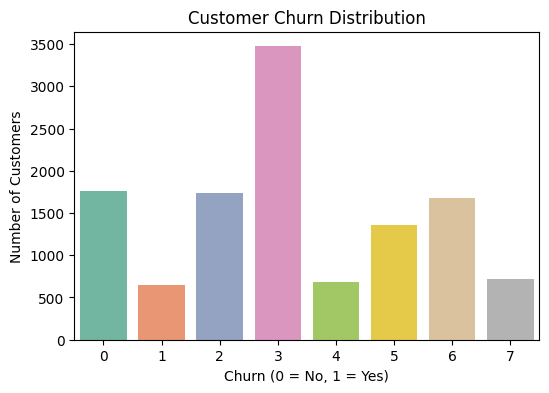

In [184]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df, palette='Set2')

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

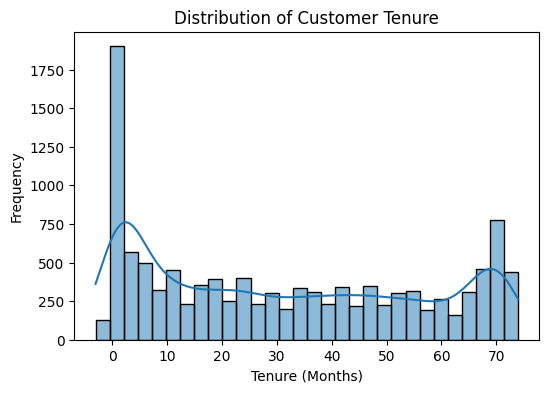

In [185]:
plt.figure(figsize=(6,4))
sns.histplot(df['tenure'], bins=30, kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")

plt.show()

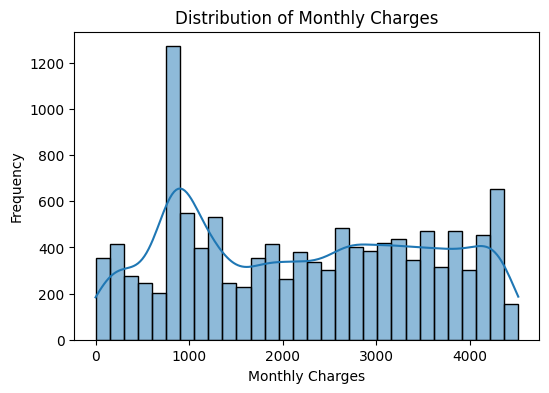

In [186]:
plt.figure(figsize=(6,4))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

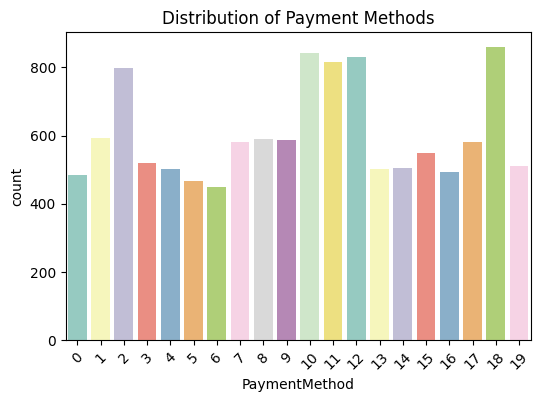

In [187]:
plt.figure(figsize=(6,4))
sns.countplot(x='PaymentMethod', data=df, palette='Set3')

plt.title("Distribution of Payment Methods")
plt.xticks(rotation=45)

plt.show()

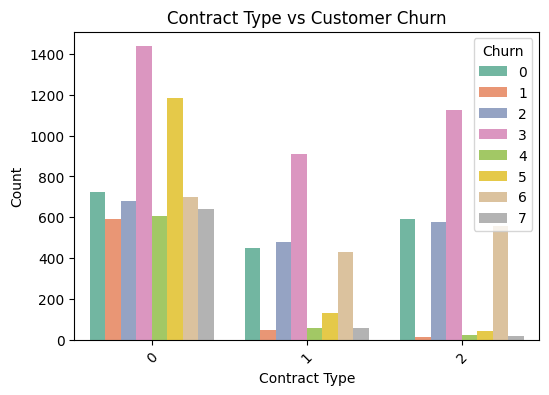

In [188]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

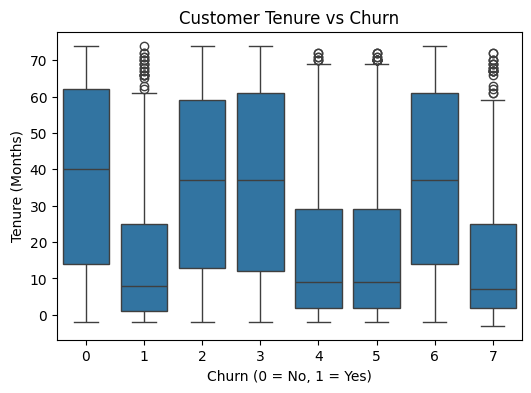

In [189]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure (Months)")

plt.show()

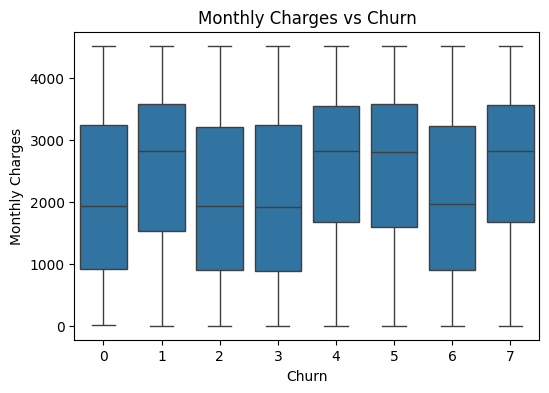

In [190]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

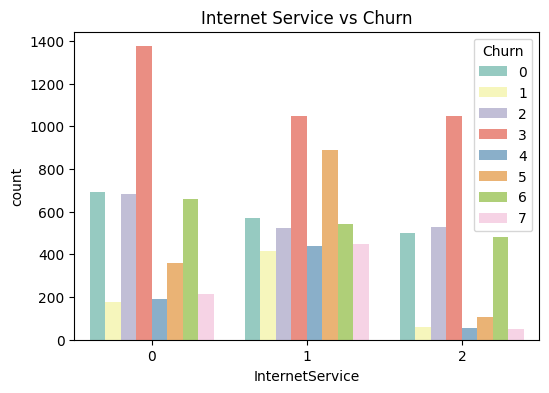

In [191]:
plt.figure(figsize=(6,4))
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set3')

plt.title("Internet Service vs Churn")

plt.show()

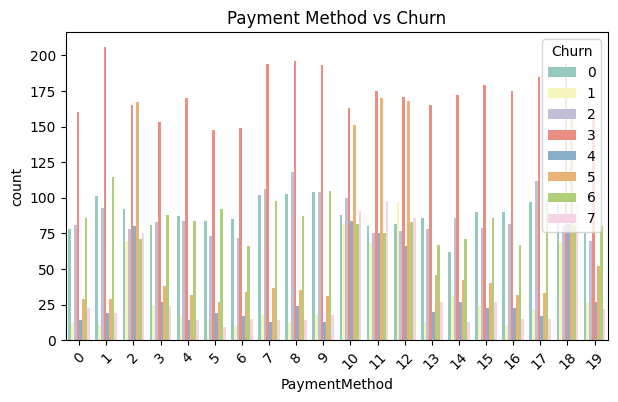

In [192]:
plt.figure(figsize=(7,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set3')

plt.title("Payment Method vs Churn")
plt.xticks(rotation=45)

plt.show()

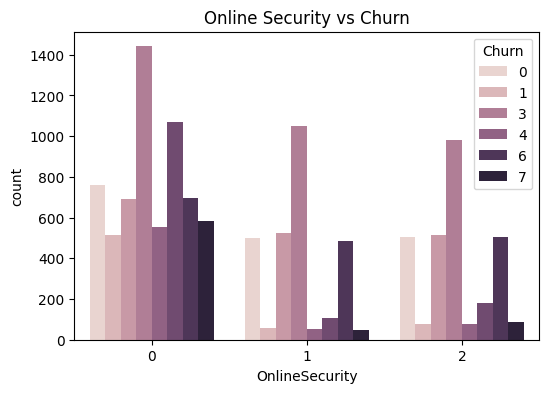

In [193]:
plt.figure(figsize=(6,4))
sns.countplot(x='OnlineSecurity', hue='Churn', data=df)

plt.title("Online Security vs Churn")

plt.show()

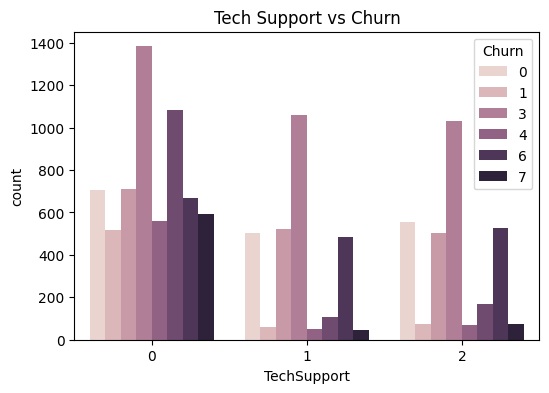

In [194]:
plt.figure(figsize=(6,4))
sns.countplot(x='TechSupport', hue='Churn', data=df)

plt.title("Tech Support vs Churn")

plt.show()

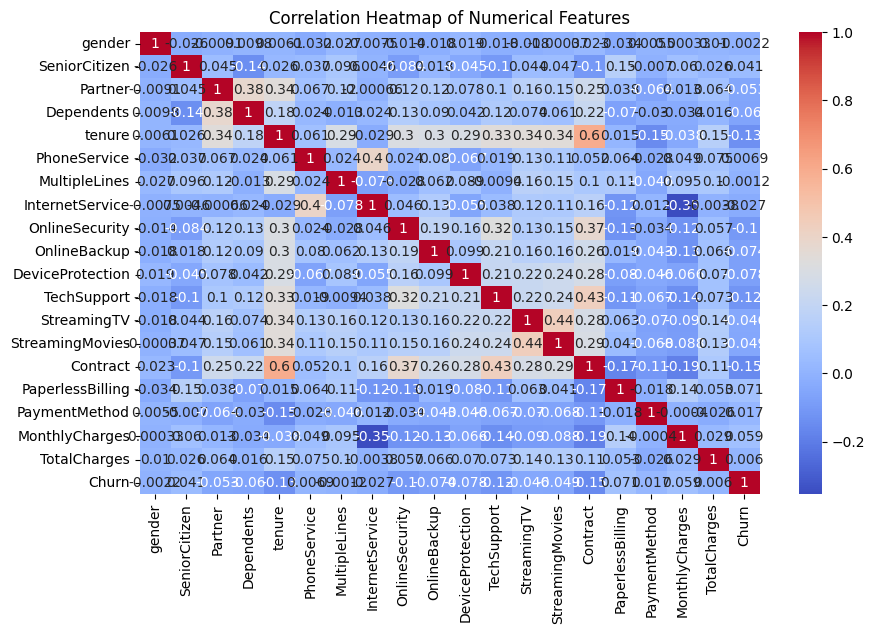

In [195]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

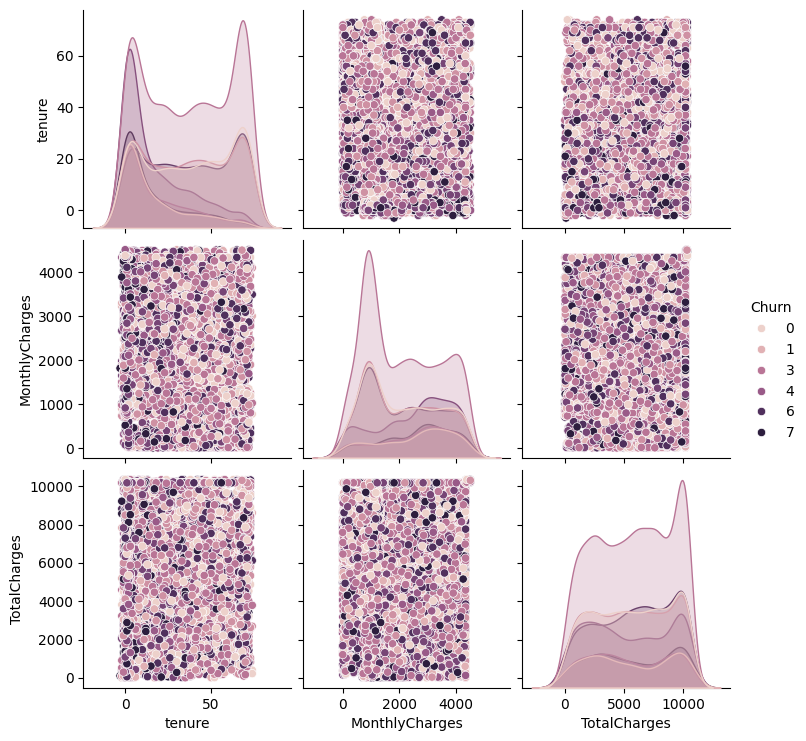

In [196]:
sns.pairplot(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']],
             hue='Churn')

plt.show()

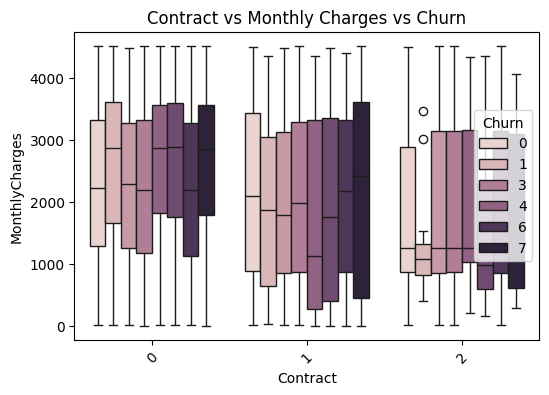

In [197]:
plt.figure(figsize=(6,4))

sns.boxplot(x='Contract', y='MonthlyCharges', hue='Churn', data=df)

plt.title("Contract vs Monthly Charges vs Churn")
plt.xticks(rotation=45)

plt.show()

In [198]:
import pandas as pd

df = pd.read_csv("/content/customer_churn (1).csv")
df.columns = df.columns.str.strip()

# Convert Churn to numeric

In [199]:
print(df['Churn'].unique())

['  No  ' 'NO' 'YES' 'yes' 'Yes' 'No' 'no' '  Yes  ']


In [200]:
df['Churn'] = df['Churn'].astype(str)

In [201]:
df['Churn'] = df['Churn'].str.lower().map({'yes':1, 'no':0, '1':1, '0':0})

In [202]:
print(df['Churn'].unique())
print(df['Churn'].dtype)

[nan  0.  1.]
float64


In [203]:
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn'] = df['Churn'].astype(str).str.lower().map({'yes':1, 'no':0, '1':1, '0':0})
df['tenure'] = df['tenure'].fillna(df['tenure'].median())
df['MonthlyCharges'] = df['MonthlyCharges'].fillna(df['MonthlyCharges'].median())
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [204]:
df = df.dropna()

In [205]:
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [206]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [209]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [212]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

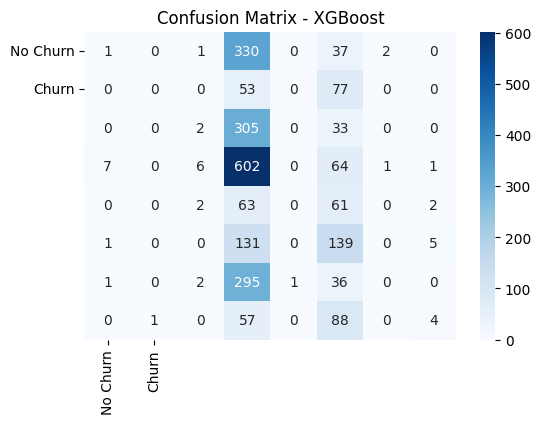

In [214]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.title("Confusion Matrix - XGBoost")
plt.show()

In [215]:
print(df.shape)

(0, 20)


In [217]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [218]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

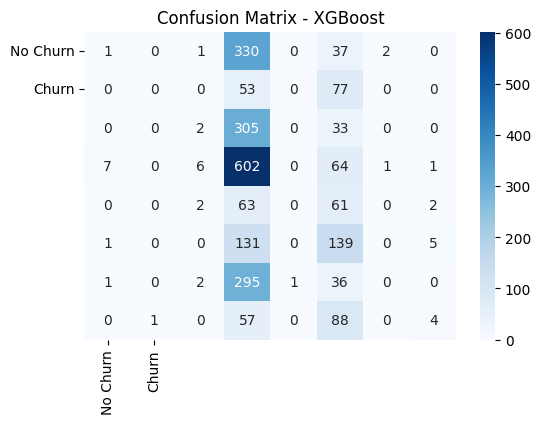

In [219]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = xgb.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.title("Confusion Matrix - XGBoost")
plt.show()

In [220]:
print(X_train_scaled.shape)

(9644, 19)
